# Streaming Signal Decomposition — Framework Demo

This notebook walks through the full SSD pipeline: signal generation,
offline block decomposition, streaming decomposition with matching,
visualization, and metrics analysis.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from experiments.synthetic.generators import (
    chirp_plus_sinusoid, two_sinusoids, rossler
)
from src.ssd.core import SSD
from src.streaming.window_manager import WindowManager
from src.streaming.component_matcher import ComponentMatcher
from src.streaming.trajectory_store import TrajectoryStore
from src.metrics.stability import qrf, nmse
from src.visualization import (
    plot_decomposition, plot_trajectory_overlay,
    plot_component_spectra, plot_metrics_over_windows,
    plot_pipeline_dashboard
)

FS = 1000.0
print("Imports OK")

Imports OK


## 1. Synthetic Signal: Chirp + Sinusoid (SNR = 20 dB)

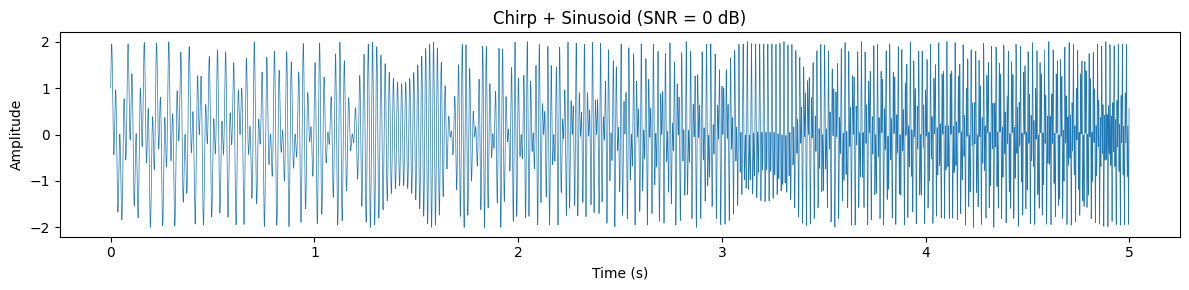

Signal shape: (5000,), fs = 1000.0 Hz


In [2]:
signal = chirp_plus_sinusoid(
    N=5000, f_sin=50, f_start=10, f_end=150,
    fs=FS, snr_db=None, seed=42,
)

t = np.arange(len(signal)) / FS
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, signal, linewidth=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Chirp + Sinusoid (SNR = 0 dB)")
plt.tight_layout()
plt.show()

print(f"Signal shape: {signal.shape}, fs = {FS} Hz")

## 2. Offline Block SSD Decomposition

In [3]:
ssd = SSD(fs=FS)
components = ssd.fit(signal)
residual = components[-1]

plot_decomposition(
    signal, components[:-1], residual, fs=FS,
    save_path="../results/demo_decomposition.png",
)

print(f"Components extracted: {len(components) - 1}")
for i, c in enumerate(components[:-1]):
    print(f"  Component {i + 1}: QRF = {qrf(signal, c):.1f} dB")

Components extracted: 5
  Component 1: QRF = 4.8 dB
  Component 2: QRF = 0.4 dB
  Component 3: QRF = 0.8 dB
  Component 4: QRF = 0.1 dB
  Component 5: QRF = 0.1 dB


## 3. Streaming Pipeline (W=300, Δ=30)

In [4]:
wm = WindowManager(window_len=300, stride=30, fs=FS)
ssd_s = SSD(fs=FS)
matcher = ComponentMatcher(distance="d_corr", fs=FS)
store = TrajectoryStore(max_components=4, max_len=len(signal))

prev_components = []
n_windows = 0

for t_idx, sample in enumerate(signal):
    window = wm.push(float(sample))
    if window is None:
        continue

    comps = ssd_s.fit(window)
    comps_no_res = comps[:-1]

    if prev_components:
        matching = matcher.match(
            prev_components, comps_no_res, wm.overlap,
        )
    else:
        matching = {i: None for i in range(len(comps_no_res))}

    window_start = t_idx - wm.window_len + 1
    store.update(window_start, comps_no_res, matching, wm.overlap)
    prev_components = comps_no_res
    n_windows += 1

print(f"Windows processed: {n_windows}")
print(f"Trajectories stored: {len(store.get_all())}")

Windows processed: 157
Trajectories stored: 27


## 4. Component Trajectory Overlay

In [5]:
plot_trajectory_overlay(
    store, signal, fs=FS,
    save_path="../results/demo_trajectories.png",
)

## 5. Component Spectra (Block SSD)

In [6]:
plot_component_spectra(
    components[:-1], fs=FS,
    save_path="../results/demo_spectra.png",
)

## 6. Streaming Pipeline Metrics

In [7]:
from experiments.run_experiment import run

run(
    config_path="../experiments/configs/baseline.yaml",
    output_dir="../results/demo_run",
)
plot_metrics_over_windows(
    "../results/demo_run/metrics.csv",
    save_path="../results/demo_metrics.png",
)

Streaming: 100%|██████████| 30000/30000 [01:19<00:00, 378.72it/s] 


## 7. Matcher Strategy Comparison

In [8]:
from pathlib import Path

comp_path = Path("../results/matcher_comparison.csv")
if comp_path.exists():
    df_cmp = pd.read_csv(comp_path)
    display(
        df_cmp.style
        .highlight_max(
            subset=["mean_confidence", "mean_qrf"],
            color="lightgreen",
        )
        .highlight_min(
            subset=["mean_freq_drift"],
            color="lightgreen",
        )
    )
else:
    print(
        "Run `python experiments/compare_matchers.py` first "
        "to generate the comparison CSV."
    )

,strategy,freq_weight,mean_confidence,mean_freq_drift,mean_qrf,std_qrf
0,d_corr,0.000000,0.881689,2737.197733,inf,nan
1,d_freq,1.000000,-9.465877,2737.197733,inf,nan
2,hybrid,0.300000,0.909912,2737.197733,inf,nan
3,hybrid,0.500000,0.928950,2737.197733,inf,nan


## 8. Robustness: QRF vs SNR Level

In [9]:
rows = []
for snr in [5, 10, 20, 40]:
    sig = two_sinusoids(
        N=2000, f1=10, f2=50, fs=500, snr_db=snr, seed=0,
    )
    ssd_r = SSD(fs=500.0)
    comps_r = ssd_r.fit(sig)
    qrf_vals = [
        qrf(sig, c) for c in comps_r[:-1]
    ]
    mean_qrf = float(np.mean(qrf_vals)) if qrf_vals else float("nan")
    rows.append({
        "SNR (dB)": snr,
        "n_components": len(comps_r) - 1,
        "mean_QRF (dB)": round(mean_qrf, 2),
    })

df_robust = pd.DataFrame(rows)
display(df_robust)

,SNR (dB),n_components,mean_QRF (dB)
0,5,6,0.92
1,10,6,0.97
2,20,2,3.02
3,40,2,3.05


## 9. Full Pipeline Dashboard

In [10]:
plot_pipeline_dashboard(
    signal, components[:-1], store,
    "../results/demo_run/metrics.csv",
    fs=FS,
    save_path="../results/demo_dashboard.png",
)
print("Dashboard saved to ../results/demo_dashboard.png")

Dashboard saved to ../results/demo_dashboard.png
